# <font color=#0099CC>**Notebook 2: EDA y Preparación de Datos**</font>

En este notebook se realiza el análisis exploratorio y la preparación de los datos para el backtesting de la estrategia Momentum:

- **Estructura de los datos**: revisión del histórico S&P 500 y del SPY.
- **Retornos logarítmicos**: cálculo mensual por activo (requerido por el enunciado para las señales de momentum).
- **Precios mensuales**: open y close al último día hábil de cada mes, para el motor de backtest y el universo de inversión.

In [1]:
# Librerías
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Permite importar utilidades compartidas desde la raíz del proyecto
project_root = Path.cwd().resolve()
if not (project_root / 'notebook_utils.py').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from notebook_utils import configure_notebook_display, get_project_paths

# Configuración de visualización (homogénea y reutilizable)
configure_notebook_display(max_columns=None, max_rows=100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Rutas del proyecto centralizadas
PATHS = get_project_paths(project_root)
DATASETS_DIR = PATHS.datasets
OUTPUTS_DIR = PATHS.outputs

> <u>Nota</u>: Este notebook reutiliza el módulo común `notebook_utils.py` para evitar duplicación de lógica (rutas/configuración) y mantener una estructura más modular y mantenible. El código y los comentarios siguen un formato homogéneo orientado a PEP 8.

## <font color=#0099CC>**1. CARGA DE DATOS**</font>

### <font color=#336699>**1.1. Lectura desde Notebook 1**</font>

Se cargan el histórico del S&P 500 y el benchmark SPY desde los Parquet generados en el Notebook 1.

In [2]:
# Cargar datos del S&P 500
df_sp500 = pd.read_parquet(DATASETS_DIR / 'sp500_history.parquet')

# Cargar datos del SPY
spy = pd.read_parquet(DATASETS_DIR / 'spy_benchmark.parquet')

print(f"> Datos S&P 500 cargados: {df_sp500.shape}")
print(f"> Datos SPY cargados: {spy.shape}")

> Datos S&P 500 cargados: (7250110, 14)
> Datos SPY cargados: (6588, 5)


> <u>Comentario</u>: Las dimensiones confirman que disponemos del histórico completo del S&P 500 (por fecha y símbolo) y de la serie diaria del SPY. A partir de ellas se construirán las tablas pivot de precios y los retornos mensuales.

## <font color=#0099CC>**2. EXPLORACIÓN DE ESTRUCTURAS**</font>

### <font color=#336699>**2.1. Estructura del histórico del S&P 500**</font>

Se inspeccionan forma, columnas y rango de fechas del DataFrame de precios diarios del S&P 500.

In [3]:
# EXPLORACIÓN DE LA ESTRUCTURA DEL HISTÓRICO S&P 500
print('> EXPLORACIÓN DE LA ESTRUCTURA DEL HISTÓRICO S&P 500')

# Verificar forma del DataFrame
print(f"\nForma del DataFrame: {df_sp500.shape}")

# Verificar columnas disponibles en el DataFrame
print("\nColumnas disponibles:")
for col in df_sp500.columns:
    print(f"  - {col}")

# Convertir columna 'date' a tipo fecha y en índice
df_sp500['date'] = pd.to_datetime(df_sp500['date'])
df_sp500 = df_sp500.set_index('date')

# Verificar periodo temporal que abarca el DataFrame
print("\nRango de fechas:")
start_date_parquet = df_sp500.index.min().date()
end_date_parquet = df_sp500.index.max().date()

print(f"  - Start Date: {start_date_parquet}")
print(f"  - End Date: {end_date_parquet}")

# Mostrar DataFrame
print(f"\nPrimeras filas:")
display(df_sp500.head())

> EXPLORACIÓN DE LA ESTRUCTURA DEL HISTÓRICO S&P 500

Forma del DataFrame: (7250110, 14)

Columnas disponibles:
  - date
  - symbol
  - assetid
  - security_name
  - sector
  - industry
  - subsector
  - in_sp500
  - open
  - high
  - low
  - close
  - volume
  - unadjusted_close

Rango de fechas:
  - Start Date: 1990-01-02
  - End Date: 2026-01-30

Primeras filas:


,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
date,,,,,,,,,,,,,
1999-11-18,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,27.188307,29.877260,23.901808,25.545057,74862288.0,42.7500
1999-11-19,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.657097,25.694445,23.789768,24.349968,18236110.0,40.7500
1999-11-22,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,24.686087,26.067909,23.939156,26.067909,7874048.5,43.6250
1999-11-23,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.395672,26.067909,24.051195,24.051195,7153099.0,40.2500
1999-11-24,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,23.976501,25.059551,23.901808,24.536699,5797720.5,41.0625


> <u>Comentario</u>: La estructura del histórico S&P 500 (forma, columnas, rango de fechas) confirma que tenemos los precios diarios y el flag de pertenencia al índice necesarios para construir el universo y los retornos mensuales en los siguientes pasos.

### <font color=#336699>**2.2. Análisis de tickers duplicados o muy parecidos**</font>

#### **2.2.1. Detección de tickers duplicados**

Se identifican símbolos que comparten la misma "base" (misma empresa con distinto sufijo, p. ej. por salida del índice o por clase de acción) o que son variantes conocidas de la misma empresa (e.j.: GOOG/GOOGL).

In [4]:
# Tickers duplicados: dos criterios

# 1) Por base del ticker: parte antes del guion. Ej: AGN-201503 y AGN-202005 -> base "AGN"
all_symbols = df_sp500['symbol'].dropna().unique().tolist()
def base_ticker(s):
    return str(s).split('-')[0].strip() if pd.notna(s) else ''
base_to_symbols = {}
for s in all_symbols:
    b = base_ticker(s)
    base_to_symbols.setdefault(b, []).append(s)
duplicated_bases = {b: syms for b, syms in base_to_symbols.items() if len(syms) > 1}
duplicated_bases = dict(sorted(duplicated_bases.items(), key=lambda x: -len(x[1])))

print("--------------  DUPLICADOS POR BASE DE TICKER --------------")
print("\n> Total de símbolos que comparten base (ej. base AGN → AGN-201503, AGN-202005):")
display(pd.DataFrame({
    'Métrica': ['Bases con más de un símbolo', 'Símbolos involucrados'],
    'Valor': [len(duplicated_bases), sum(len(s) for s in duplicated_bases.values())]
}))
print("> Ejemplos de símbolos que comparten base y cuántos son (N):")
display(pd.DataFrame([
    {'Base': base, 'Símbolos': ', '.join(syms), 'N': len(syms)}
    for base, syms in list(duplicated_bases.items())[:5]
]))


# 2) Por nombre de empresa normalizado (quita Class A/C, Common, etc.) -> detecta GOOG/GOOGL, etc.
df_one = df_sp500.groupby('symbol').agg({'security_name': 'first'}).reset_index()
def norm_name(name):
    if pd.isna(name):
        return ''
    s = str(name).upper().replace(' CLASS A', '').replace(' CLASS B', '').replace(' CLASS C', '')
    s = s.replace(' COMMON', '').replace(' INC', '').replace('.', ' ')
    return ' '.join(s.split())
df_one['name_norm'] = df_one['security_name'].map(norm_name)
name_to_symbols = df_one.groupby('name_norm')['symbol'].apply(list).to_dict()
same_name = {k: v for k, v in name_to_symbols.items() if len(v) > 1}

print("\n--------------  DUPLICADOS POR CLASE DE ACCIÓN --------------")
print("\n> Empresas que tienen distintas clases de acciones (ej. GOOG/GOOGL)")
display(pd.DataFrame({
    'Métrica': ['Grupos con mismo nombre'],
    'Valor': [len(same_name)]
}))
print("> Ejemplos de símbolos que comparten nombre y cuántos son (N):")
display(pd.DataFrame([
    {
        'Nombre (ejemplo)': str(df_one[df_one['symbol'] == syms[0]]['security_name'].iloc[0])[:50],
        'Símbolos': ', '.join(syms),
        'N': len(syms)
    }
    for name_norm, syms in list(same_name.items())[:5]
]))
print("> Comprobación: security_name crudo por símbolo en cada grupo (por si hay falsos positivos, ej. ¿BGEN vs BIIB?):")
for name_norm, syms in list(same_name.items())[:5]:
    rows = df_one[df_one['symbol'].isin(syms)][['symbol', 'security_name']].drop_duplicates()
    display(rows)

--------------  DUPLICADOS POR BASE DE TICKER --------------

> Total de símbolos que comparten base (ej. base AGN → AGN-201503, AGN-202005):


,Métrica,Valor
0,Bases con más de un símbolo,44
1,Símbolos involucrados,88


> Ejemplos de símbolos que comparten base y cuántos son (N):


,Base,Símbolos,N
0,AAL,"AAL-199702, AAL",2
1,AGN,"AGN-201503, AGN-202005",2
2,AMP,"AMP-199904, AMP",2
3,AMT,"AMT-199607, AMT",2
4,AN,"AN-199812, AN",2



--------------  DUPLICADOS POR CLASE DE ACCIÓN --------------

> Empresas que tienen distintas clases de acciones (ej. GOOG/GOOGL)


...

,symbol,security_name
527,GOOG,Alphabet Inc Class C Common
528,GOOGL,Alphabet Inc Class A Common


,symbol,security_name
145,BGEN-200311,Biogen Common
150,BIIB,Biogen Inc Common


,symbol,security_name
251,CIT-200106,CIT Group Inc Class A Common
252,CITGQ-200912,CIT Group Inc Common


,symbol,security_name
331,DAL,Delta Air Lines Inc Common
332,DALRQ-200704,Delta Air Lines Common


,symbol,security_name
347,DG,Dollar General Corp Common
348,DG-200707,Dollar General Corp Common


> <u>Comentario</u>: ¿Qué diferencia hay entre los dos criterios?
>
> - <u>Duplicados por base del ticker</u>: agrupa por la parte antes del guion. Solo detecta cuando hay variantes como 'AGN' y 'AGN-201503' (misma base 'AGN'). NO detecta GOOG vs GOOGL porque las bases son 'GOOG' y 'GOOGL' (distintas).
> - <u>Duplicados por nombre de empresa</u>: agrupa por nombre de la empresa. SÍ detecta GOOG y GOOGL (misma empresa, Alphabet) y también los casos de la tabla anterior cuando el nombre coincide.

#### **2.2.1. Limpieza de duplicados**

En cada grupo de tickers duplicados (misma base o mismo nombre de empresa) se conserva solo el símbolo con **mayor volumen medio** y se eliminan los demás. La lógica es operativa y metodológica:

- Evita el **doble conteo económico** de una misma compañía (por ejemplo, distintas clases de acciones o variantes históricas del ticker), que distorsionaría tanto señales como pesos.
- Prioriza la serie con **mayor liquidez estructural**, que suele ofrecer mejor continuidad de precios, menor ruido por microestructura y una ejecución más realista en backtesting.
- Reduce problemas de **inestabilidad del universo** y de pivotado (columnas redundantes para la misma empresa), mejorando consistencia entre N2 (preparación), N3 (señales) y N4/N5 (ejecución y evaluación).

Es una simplificación razonable para un entorno académico: no busca modelar todas las clases de acciones simultáneamente, sino representar cada emisor una sola vez de forma robusta y reproducible.

In [5]:
# Volumen medio por símbolo (en el histórico)
vol_medio = df_sp500.groupby('symbol')['volume'].mean()

symbols_to_drop = set()
# Por base del ticker: en cada grupo quedarse con el de mayor volumen medio
for base, syms in duplicated_bases.items():
    keep = vol_medio[vol_medio.index.isin(syms)].idxmax()
    for s in syms:
        if s != keep:
            symbols_to_drop.add(s)
# Por nombre de empresa: en cada grupo quedarse con el de mayor volumen medio
for name_norm, syms in same_name.items():
    keep = vol_medio[vol_medio.index.isin(syms)].idxmax()
    for s in syms:
        if s != keep:
            symbols_to_drop.add(s)

df_sp500 = df_sp500[~df_sp500['symbol'].isin(symbols_to_drop)]
print(f'> Deduplicación por volumen: eliminados {len(symbols_to_drop)} símbolos (mantenido el de mayor volumen por grupo).')
print(f'> Filas en df_sp500 tras filtro: {len(df_sp500):,}')

# Guardar histórico deduplicado para uso en N3 (universo) y N4 (precios diarios)
dedup_path = DATASETS_DIR / 'sp500_history_deduplicated.parquet'
df_sp500.reset_index().to_parquet(dedup_path)
print(f'> Guardado: {dedup_path} (para N3 y N4)')


> Deduplicación por volumen: eliminados 55 símbolos (mantenido el de mayor volumen por grupo).
> Filas en df_sp500 tras filtro: 7,043,936
> Guardado: C:\Users\Javi\Desktop\backtesting\datasets\sp500_history_deduplicated.parquet (para N3 y N4)


### <font color=#336699>**2.3. Estructura del benchmark SPY (S&P 500 ETF Trust)**</font>

Se revisa la forma, columnas y rango temporal del DataFrame del SPY cargado desde el Notebook 1.

In [6]:
# EXPLORACIÓN DE LA ESTRUCTURA DEL SPY (S&P 500 ETF Trust)
print('> EXPLORACIÓN DE LA ESTRUCTURA DEL SPY (S&P 500 ETF Trust)')

# Verificar forma del DataFrame
print(f"\nForma del DataFrame: {spy.shape}")

# Verificar columnas disponibles en el DataFrame
print("\nColumnas disponibles:")
for col in spy.columns:
    print(f"  - {col}")

# Asegurar índice datetime
spy.index = pd.to_datetime(spy.index)

# Verificar periodo temporal que abarca el DataFrame
print("\nRango de fechas:")
start_date = spy.index.min().date()
end_date = spy.index.max().date()

print(f"  - Start Date: {start_date}")
print(f"  - End Date: {end_date}")

print("\nPrimeras filas SPY:")
display(spy.head())

> EXPLORACIÓN DE LA ESTRUCTURA DEL SPY (S&P 500 ETF Trust)

Forma del DataFrame: (6588, 5)

Columnas disponibles:
  - ('Close', 'SPY')
  - ('High', 'SPY')
  - ('Low', 'SPY')
  - ('Open', 'SPY')
  - ('Volume', 'SPY')

Rango de fechas:
  - Start Date: 1999-11-18
  - End Date: 2026-01-29

Primeras filas SPY:


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
1999-11-18,89.625366,89.861016,88.996967,89.507541,4491000
1999-11-19,89.546768,89.841330,89.232569,89.487856,4832100
1999-11-22,89.527184,89.861020,88.918422,89.507546,4155400
1999-11-23,88.741676,89.762824,88.211465,89.762824,5918000
1999-11-24,89.212967,89.507529,87.975807,88.447106,4459700


> <u>Comentario</u>: El SPY tiene precios Open, High, Low, Close y Volume. En el backtest se utilizará la serie de cierre para el benchmark; el Notebook 4 la tomará ya en formato adecuado.

## <font color=#0099CC>**3. PREPARACIÓN DE DATOS EN FORMATO WIDE (PIVOT)**</font>

Se reorganizan los datos para disponer de matrices **fecha × símbolo** con precios close (y open) ajustados, necesarias para el cálculo de retornos mensuales y para el motor de backtest.

### <font color=#336699>**3.1. S&P 500: pivot por fecha y símbolo**</font>

In [7]:
# Tablas pivot que contienen precios close ajustados ordenados por fecha y símbolo

df_prices_open = df_sp500.pivot_table(
    index=df_sp500.index,  # mantener el índice original
    columns="symbol",
    values="open",
    aggfunc="last"
)

df_prices_close = df_sp500.pivot_table(
    index=df_sp500.index,  # mantener el índice original
    columns="symbol",
    values="close",
    aggfunc="last"
)

# Asegurarse de que el índice es DatetimeIndex
df_prices_open.index = pd.to_datetime(df_prices_open.index)
df_prices_close.index = pd.to_datetime(df_prices_close.index)

# Orden temporal
df_prices_open = df_prices_open.sort_index()
df_prices_close = df_prices_close.sort_index()
df_prices_open.head()

symbol,A,AABA-201910,AAL,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,ABKFQ-201304,ABMD-202212,ABNB,ABS-200606,ABT,ACAS-201701,ACGL,ACKH-200712,ACN,ACS-201002,ACV-201105,ACY-199411,ADBE,ADCT-201012,ADI,ADM,ADP,ADSK,ADT-201604,AEE,AEP,AES,AET-201811,AFL,AFS-200011,AGC-200108,AGN-201503,AHM-199810,AIG,AIT-199910,AIV,AIZ,AJG,AKAM,AKS-202003,AL-200711,ALB,ALGN,ALK,ALL,ALLE,ALTR-201512,ALXN-202107,AM-201308,AMAT,AMCC-201701,AMCR,AMD,AME,AMG,AMGN,AMH-199709,AMP,AMT,AMTM,AMX-199311,AMZN,AN-199812,ANDV-201809,ANDW-200712,ANET,ANF,ANRZQ-201607,ANSS-202507,ANV-199904,AON,AOS,APA,APC-201908,APCC-200702,APD,APH,APO,APOL-201702,APP,APTV,AR-199911,ARC-200004,ARE,ARES,ARG-201605,AS-199909,ASC-199906,ASH,ASN-200710,ASND-199906,ASO-200611,AT-200711,ATGE,ATI-199906,ATO,ATVI-202310,AV-200710,AVB,AVGO,AVP-202001,AVY,AW-200812,AWE-200410,AWK,AXON,AXP,AYE-201102,AYI,AZA-200106,AZO,B,BA,BAC,BALL,BAX,BAY-199808,BBBYQ-202309,BBI-199801,BBWI,BBY,BC,BCO,BCR-201712,BDK-201003,BDX,BEAM-201404,BEN,BEV-200603,BF.B,BFH,BFI-199907,BFO-200010,BG,BGEN-200311,BGGSQ-202101,BHF,BHMSQ-200401,BIGGQ,BIO,BJS-201004,BK,BKB-199909,BKNG,BKR,BLDR,BLK,BLS-200612,BLY-199612,BMC-201309,BMET-200709,BMG-200101,BMS-201906,BMY,BN-199503,BNI-201002,BNL-199806,BNSSA-201206,BOAT-199701,BOL-200710,BR-200603,BRCM-201601,BRK.B,BRL-200812,BRNO-199508,BRO,BSC-200805,BSET,BSX,BT-199906,BTUUQ-201704,BUD-200811,BV-199409,BVSN-202005,BWA,BWY-199510,BX,BXLT-201606,BXP,C,CA-201811,CAG,CAH,CAL,CAM-201604,CAR,CARR,CAT,CB-201601,CBB-199801,CBE-201211,CBH-200803,CBL-199010,CBOE,CBRE,CBS-200005,CBSS-200709,CCB-199602,CCEP,CCI,CCK,CCL,CCTYQ-201109,CCU-200807,CDNS,CDW,CE-200402,CEG,CELG-201911,CEN-200711,CEPH-201110,CERN-202206,CF,CFC-200806,CFG,CFL-199804,CFN-201503,CG-200011,CGP-200101,CHA-200006,CHD,CHIR-200604,CHKAQ-202102,CHRS-201206,CHRW,CHTR,CI,CIC-199505,CIEN,CIN-200603,CINF,CITGQ-200912,CKL-199505,CL,CLF,CLX,CMA,CMB-199603,CMCSA,CMCSK-201512,CME,CMG,CMI,CMS,CMVT-201302,CMX-200703,CNA,CNC,CNCEQ-200309,CNG-200001,CNP,CNW-201510,CNX,CNXT-201104,COC-200208,COF,COIN,COL-201811,COMS-201004,COO,COP,COR,COST,COTY,COV-201501,CPAY,CPB,CPGX-201606,CPNLQ-200802,CPPRQ-202102,CPQ-200205,CPRI,CPRT,CPT,CPWR-201412,CRH,CRL,CRM,CRR-199706,CRWD,CSCO,CSE-199911,CSGP,CSR-200006,CSRA-201804,CSX,CTAS,CTB-202106,CTCO-199110,CTLT-202412,CTRA,CTSH,CTVA,CTX-200908,CTXS-202209,CUE-199309,CVC-201606,CVG-201810,CVGQE-200412,CVH-201305,CVN-199112,CVNA,CVS,CVX,CXO-202101,CXT,CYM-199912,CYR-199606,CZR,D,DAL,DASH,DAY,DCNAQ-200801,DD,DDOG,DDS,DE,DEC-199806,DECK,DELL-201310,DFODQ-202106,DFS-202505,DG,DGN-199910,DGX,DHI,DHR,DI-199809,DIGI-199809,DINO,DIS,DISCK-202204,DISH-202312,DJ-200712,DLR,DLTR,DLX,DNB-201902,DNRCQ-202009,DOC,DOFSQ-202104,DOV,DOW-201708,DPHIQ-200910,DPZ,DRE-202209,DRI,DTE,DTV-201507,DUK,DVA,DVN,DWD-199705,DXC,DXCM,DYHGQ-200012,DYN-201804,E-199504,EA,EBAY,EC-200606,ECH-199807,ECL,ECO-200301,ED,EDS-200808,EFU-200011,EFX,EG,EHC,EIX,EKDKQ-201309,EL,ELV,EMC-201609,EME,EMN,EMR,ENDPQ-202405,ENPH,ENRNQ-200411,ENS-199708,EOG,EOP-200702,EP-201205,EPAM,EQ-200906,EQIX,EQR,EQT,ERIE,ES,ESRX-201812,ESS,ESY-199505,ETFC-202010,ETN,ETR,ETS-200603,ETSY,EVHC-201810,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FBF-200403,FBIN,FBO-199603,FCN-199810,FCX,FDC-200709,FDO-201507,FDS,FDX,FE,FFB-199512,FFIV,FG-199804,FHI,FHN,FICO,FIS,FISV,FITB,FIX,FJ-200011,FJCC-200809,FL-202509,FLIR-202105,FLMIQ-200408,FLR,FLS,FLTWQ-200907,FMC,FMCC,FMY-199905,FNB-199511,FNMA,FOSL,FOXA,FPC-200011,FRCB,FRM-199612,FRO-199909,FRT,FRX-201406,FSH-200611,FSL.B-200612,FSLR,FTI,FTL-200004,FTNT,FTRCQ-202104,FTV,FWLT-201412,G-200509,GAP,GAPTQ-201203,GAS-201606,GBLXQ-200312,GCO,GD,GDDY,GDT-200604,GDW-200609,GE,GEB-199408,GEHC,GEN,GENZ-201104,GEV,GFS.A-199810,GGP-201808,GHC-199308,GIC-200001,GIDL-199709,GILD,GIS,GL,GLD-199705,GLK-200507,GLW,GM,GMCR-201603,GME,GNE-199906,GNN-199006,GNRC,GNT-199806,GNW,GOOGL,GOSHA-200507,GP-200512,GPC,GPN,GPU-200111,GQ-199404,GR-201207,GRA-202109,GRMN,GRN-199812,GS,GSX-199810,GT,GTE-200006,GTW-200710,GWF-199707,GWOW-201009,GWW,H-20

> <u>Comentario</u>: La tabla pivot de precios close (fecha × símbolo) permite calcular retornos mensuales y, junto con la serie del SPY, da la base para el universo de inversión y el benchmark en los siguientes notebooks.

### <font color=#336699>**3.2. Benchmark SPY: serie de cierre**</font>

Se extrae la columna de cierre del SPY y se alinea al rango de fechas del backtest para su uso como benchmark.

In [8]:
# Extraer solo la columna de cierre
df_spy_close = spy['Close'].copy()

# Convertir el índice a datetime
df_spy_close.index = pd.to_datetime(df_spy_close.index)

# Renombrar el índice
df_spy_close.index.name = 'date'

# Renombramos la columna actual 'SPY'
df_spy_close = df_spy_close.rename(columns={'SPY': 'SPY_benchmark'})

# Cambiamos el nombre de la columna para que sea 'symbol'
df_spy_close.columns.name = 'symbol'

# Mostrar resultado
df_spy_close.head()

symbol,SPY_benchmark
date,
1999-11-18,89.625366
1999-11-19,89.546768
1999-11-22,89.527184
1999-11-23,88.741676
1999-11-24,89.212967


> <u>Comentario</u>: De esta forma ambos datasets tienen estructuras similares, lo cuál facilitará operaciones entre ellos posteriormente.

## <font color=#0099CC>**4. FILTRADO DEL UNIVERSO DE INVERSIÓN POR FECHAS**</font>

Se restringen los datos al periodo necesario para el backtest (desde noviembre 2013 para poder calcular momentum en enero 2015 sin look-ahead). El criterio de qué activos forman el universo (13 meses consecutivos en el S&P) se aplica en el Notebook 3.

### <font color=#336699>**4.1. S&P 500 en el periodo de backtest**</font>

In [9]:
# Definir periodo de backtesting
backtest_start = pd.Timestamp('2015-01-01')
backtest_end = pd.Timestamp('2026-01-30')

# Encontrar la última fecha de noviembre 2013 en df_prices_close
last_nov2013 = df_prices_close[(df_prices_close.index.year == 2013) &
                               (df_prices_close.index.month == 11)].index.max()
print(f"Última fecha de noviembre 2013: {last_nov2013.date()}")

# Filtrar precios desde esa fecha hasta el final del backtest
prices_close_flt = df_prices_close.loc[last_nov2013 : backtest_end].copy()
prices_open_flt = df_prices_open.loc[last_nov2013 : backtest_end].copy()

# Comprobación rápida
print(f"> Rango de fechas filtrado: {prices_close_flt.index.min().date()} a {prices_close_flt.index.max().date()}")
print(f"> Shape de precios filtrados: {prices_close_flt.shape}")

Última fecha de noviembre 2013: 2013-11-29
> Rango de fechas filtrado: 2013-11-29 a 2026-01-30
> Shape de precios filtrados: (3060, 1234)


### <font color=#336699>**4.2. Benchmark SPY en el periodo de backtest**</font>

In [10]:
# Definir periodo de backtesting
backtest_start = pd.Timestamp('2015-01-01')
backtest_end = pd.Timestamp('2026-01-30')

# Encontrar la última fecha de noviembre 2013 en df_spy_close
last_nov2013_spy = df_spy_close[(df_spy_close.index.year == 2013) &
                               (df_spy_close.index.month == 11)].index.max()
print(f"Última fecha de noviembre 2013: {last_nov2013_spy.date()}")

# Filtrar precios desde esa fecha hasta el final del backtest
prices_close_flt_spy = df_spy_close.loc[last_nov2013_spy : backtest_end].copy()

# Nota: para el SPY solo necesitamos precios de cierre para el benchmark mensual.
# Si en notebooks posteriores quisiéramos simular ejecución open/close del SPY,
# habría que construir explícitamente una serie de precios de apertura.

# Comprobación rápida
print(f"> Rango de fechas filtrado: {prices_close_flt_spy.index.min().date()} a {prices_close_flt_spy.index.max().date()}")
print(f"> Shape de precios filtrados: {prices_close_flt_spy.shape}")

Última fecha de noviembre 2013: 2013-11-29
> Rango de fechas filtrado: 2013-11-29 a 2026-01-29
> Shape de precios filtrados: (3059, 1)


> <u>Comentario</u>: Para garantizar la ausencia de look-ahead bias y poder calcular correctamente las variables de momentum (t-13 a t-1) del primer mes del backtest (enero 2015), se requiere disponer de precios desde noviembre de 2013. En concreto: R_12 en ese rebalanceo usa los retornos de diciembre 2013 a diciembre 2014; el retorno de diciembre 2013 es ln(P_dic/P_nov), por lo que necesitamos el cierre de noviembre 2013. De ahí que el filtro de precios empiece en el último día hábil de noviembre de 2013.

> <u>Nota</u>: Los Parquet de retornos mensuales y de precios mensuales (open/close) se guardan en `../datasets/` para el Notebook 3 (señales de momentum) y el Notebook 4 (precios diarios se construyen allí a partir del histórico).

## <font color=#0099CC>**5. CÁLCULO DE RETORNOS LOGARÍTMICOS MENSUALES**</font>

Se calculan **retornos logarítmicos**. Se resamplea a mensual (último día hábil de cada mes) para evitar look-ahead: el cierre del mes solo se conoce al final del mes.

In [11]:
# Resamplear a mensual usando el último precio de cada mes
# Esto evita look-ahead bias: solo usamos datos hasta el final del mes

df_monthly_close = prices_close_flt.resample('ME').last() # Último precio del mes (día de rebalanceo)
df_monthly_open = prices_open_flt.resample('ME').last()   # Open del último día hábil del mes (día de rebalanceo), no .first()

# Calcular retornos logarítmicos mensuales
# log_return = ln(P_t / P_{t-1})
df_log_returns = np.log(df_monthly_close / df_monthly_close.shift(1))

# Eliminar primera fila (NaN por shift)
df_log_returns = df_log_returns.iloc[1:]

print(f"> Retornos logarítmicos mensuales calculados: {df_log_returns.shape}")
print(f"> Rango de fechas: {df_log_returns.index.min().date()} a {df_log_returns.index.max().date()}")
print(f"\n> Primeras filas de los retornos logarítimicos:")
display(df_log_returns.head())

# Guardar para uso posterior en la carpeta datasets
df_log_returns.to_parquet(DATASETS_DIR / 'log_returns_monthly.parquet')
df_monthly_close.to_parquet(DATASETS_DIR / 'monthly_close_prices.parquet')
df_monthly_open.to_parquet(DATASETS_DIR / 'monthly_open_prices.parquet')

print("\nArchivos guardados en ../datasets/:")
print("  - log_returns_monthly.parquet")
print("  - monthly_close_prices.parquet")
print("  - monthly_open_prices.parquet")
print("  - sp500_history_deduplicated.parquet (sección 2.2, usado por N3 y N4)")

> Retornos logarítmicos mensuales calculados: (146, 1234)
> Rango de fechas: 2013-12-31 a 2026-01-31

> Primeras filas de los retornos logarítimicos:


symbol,A,AABA-201910,AAL,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,ABKFQ-201304,ABMD-202212,ABNB,ABS-200606,ABT,ACAS-201701,ACGL,ACKH-200712,ACN,ACS-201002,ACV-201105,ACY-199411,ADBE,ADCT-201012,ADI,ADM,ADP,ADSK,ADT-201604,AEE,AEP,AES,AET-201811,AFL,AFS-200011,AGC-200108,AGN-201503,AHM-199810,AIG,AIT-199910,AIV,AIZ,AJG,AKAM,AKS-202003,AL-200711,ALB,ALGN,ALK,ALL,ALLE,ALTR-201512,ALXN-202107,AM-201308,AMAT,AMCC-201701,AMCR,AMD,AME,AMG,AMGN,AMH-199709,AMP,AMT,AMTM,AMX-199311,AMZN,AN-199812,ANDV-201809,ANDW-200712,ANET,ANF,ANRZQ-201607,ANSS-202507,ANV-199904,AON,AOS,APA,APC-201908,APCC-200702,APD,APH,APO,APOL-201702,APP,APTV,AR-199911,ARC-200004,ARE,ARES,ARG-201605,AS-199909,ASC-199906,ASH,ASN-200710,ASND-199906,ASO-200611,AT-200711,ATGE,ATI-199906,ATO,ATVI-202310,AV-200710,AVB,AVGO,AVP-202001,AVY,AW-200812,AWE-200410,AWK,AXON,AXP,AYE-201102,AYI,AZA-200106,AZO,B,BA,BAC,BALL,BAX,BAY-199808,BBBYQ-202309,BBI-199801,BBWI,BBY,BC,BCO,BCR-201712,BDK-201003,BDX,BEAM-201404,BEN,BEV-200603,BF.B,BFH,BFI-199907,BFO-200010,BG,BGEN-200311,BGGSQ-202101,BHF,BHMSQ-200401,BIGGQ,BIO,BJS-201004,BK,BKB-199909,BKNG,BKR,BLDR,BLK,BLS-200612,BLY-199612,BMC-201309,BMET-200709,BMG-200101,BMS-201906,BMY,BN-199503,BNI-201002,BNL-199806,BNSSA-201206,BOAT-199701,BOL-200710,BR-200603,BRCM-201601,BRK.B,BRL-200812,BRNO-199508,BRO,BSC-200805,BSET,BSX,BT-199906,BTUUQ-201704,BUD-200811,BV-199409,BVSN-202005,BWA,BWY-199510,BX,BXLT-201606,BXP,C,CA-201811,CAG,CAH,CAL,CAM-201604,CAR,CARR,CAT,CB-201601,CBB-199801,CBE-201211,CBH-200803,CBL-199010,CBOE,CBRE,CBS-200005,CBSS-200709,CCB-199602,CCEP,CCI,CCK,CCL,CCTYQ-201109,CCU-200807,CDNS,CDW,CE-200402,CEG,CELG-201911,CEN-200711,CEPH-201110,CERN-202206,CF,CFC-200806,CFG,CFL-199804,CFN-201503,CG-200011,CGP-200101,CHA-200006,CHD,CHIR-200604,CHKAQ-202102,CHRS-201206,CHRW,CHTR,CI,CIC-199505,CIEN,CIN-200603,CINF,CITGQ-200912,CKL-199505,CL,CLF,CLX,CMA,CMB-199603,CMCSA,CMCSK-201512,CME,CMG,CMI,CMS,CMVT-201302,CMX-200703,CNA,CNC,CNCEQ-200309,CNG-200001,CNP,CNW-201510,CNX,CNXT-201104,COC-200208,COF,COIN,COL-201811,COMS-201004,COO,COP,COR,COST,COTY,COV-201501,CPAY,CPB,CPGX-201606,CPNLQ-200802,CPPRQ-202102,CPQ-200205,CPRI,CPRT,CPT,CPWR-201412,CRH,CRL,CRM,CRR-199706,CRWD,CSCO,CSE-199911,CSGP,CSR-200006,CSRA-201804,CSX,CTAS,CTB-202106,CTCO-199110,CTLT-202412,CTRA,CTSH,CTVA,CTX-200908,CTXS-202209,CUE-199309,CVC-201606,CVG-201810,CVGQE-200412,CVH-201305,CVN-199112,CVNA,CVS,CVX,CXO-202101,CXT,CYM-199912,CYR-199606,CZR,D,DAL,DASH,DAY,DCNAQ-200801,DD,DDOG,DDS,DE,DEC-199806,DECK,DELL-201310,DFODQ-202106,DFS-202505,DG,DGN-199910,DGX,DHI,DHR,DI-199809,DIGI-199809,DINO,DIS,DISCK-202204,DISH-202312,DJ-200712,DLR,DLTR,DLX,DNB-201902,DNRCQ-202009,DOC,DOFSQ-202104,DOV,DOW-201708,DPHIQ-200910,DPZ,DRE-202209,DRI,DTE,DTV-201507,DUK,DVA,DVN,DWD-199705,DXC,DXCM,DYHGQ-200012,DYN-201804,E-199504,EA,EBAY,EC-200606,ECH-199807,ECL,ECO-200301,ED,EDS-200808,EFU-200011,EFX,EG,EHC,EIX,EKDKQ-201309,EL,ELV,EMC-201609,EME,EMN,EMR,ENDPQ-202405,ENPH,ENRNQ-200411,ENS-199708,EOG,EOP-200702,EP-201205,EPAM,EQ-200906,EQIX,EQR,EQT,ERIE,ES,ESRX-201812,ESS,ESY-199505,ETFC-202010,ETN,ETR,ETS-200603,ETSY,EVHC-201810,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FBF-200403,FBIN,FBO-199603,FCN-199810,FCX,FDC-200709,FDO-201507,FDS,FDX,FE,FFB-199512,FFIV,FG-199804,FHI,FHN,FICO,FIS,FISV,FITB,FIX,FJ-200011,FJCC-200809,FL-202509,FLIR-202105,FLMIQ-200408,FLR,FLS,FLTWQ-200907,FMC,FMCC,FMY-199905,FNB-199511,FNMA,FOSL,FOXA,FPC-200011,FRCB,FRM-199612,FRO-199909,FRT,FRX-201406,FSH-200611,FSL.B-200612,FSLR,FTI,FTL-200004,FTNT,FTRCQ-202104,FTV,FWLT-201412,G-200509,GAP,GAPTQ-201203,GAS-201606,GBLXQ-200312,GCO,GD,GDDY,GDT-200604,GDW-200609,GE,GEB-199408,GEHC,GEN,GENZ-201104,GEV,GFS.A-199810,GGP-201808,GHC-199308,GIC-200001,GIDL-199709,GILD,GIS,GL,GLD-199705,GLK-200507,GLW,GM,GMCR-201603,GME,GNE-199906,GNN-199006,GNRC,GNT-199806,GNW,GOOGL,GOSHA-200507,GP-200512,GPC,GPN,GPU-200111,GQ-199404,GR-201207,GRA-202109,GRMN,GRN-199812,GS,GSX-199810,GT,GTE-200006,GTW-200710,GWF-199707,GWOW-201009,GWW,H-20


Archivos guardados en ../datasets/:
  - log_returns_monthly.parquet
  - monthly_close_prices.parquet
  - monthly_open_prices.parquet
  - sp500_history_deduplicated.parquet (sección 2.2, usado por N3 y N4)


> <u>Comentario</u>: Los retornos logarítmicos mensuales y los precios mensuales (open/close) quedan guardados en Parquet. El Notebook 3 usará los retornos para las señales de momentum; el Notebook 4 usará los precios diarios construidos a partir del histórico.

## <font color=#0099CC>**6. ANÁLISIS EXPLORATORIO DE DATOS**</font>

Se revisan estadísticas básicas de los retornos logarítmicos mensuales y se visualiza una muestra de su distribución.

> Estadísticas de retornos logarítmicos mensuales:


symbol           A  AABA-201910         AAL  AAMRQ-201312         AAP  \
count   146.000000    71.000000  145.000000      1.000000  146.000000   
mean      0.009269     0.009386   -0.004014     -0.053836   -0.004159   
std       0.070404     0.082884    0.123283           NaN    0.122182   
min      -0.169313    -0.241753   -0.446451     -0.053836   -0.543593   
25%      -0.032520    -0.039913   -0.082663     -0.053836   -0.053189   
50%       0.011396     0.007671    0.000244     -0.053836   -0.002480   
75%       0.057510     0.070403    0.080272     -0.053836    0.068237   
max       0.212152     0.208720    0.284211     -0.053836    0.381755   

symbol        AAPL  AAV-199901        ABBV  ABI-200811  ABKFQ-201304  \
count   146.000000         0.0  146.000000         0.0           0.0   
mean      0.018568         NaN    0.013799         NaN           NaN   
std       0.075889         NaN    0.070891         NaN           NaN   
min      -0.199913         NaN   -0.201938         NaN           NaN   
25%      -0.033549         NaN   -0.023766         NaN           NaN   
50%       0.024460         NaN    0.014660         NaN           NaN   
75%       0.074393         NaN    0.057277         NaN           NaN   
max       0.196035         NaN    0.206125         NaN           NaN   

symbol  ABMD-202212       ABNB  ABS-200606         ABT  ACAS-201701  \
count    109.000000  61.000000         0.0  146.000000    38.000000   
mean       0.023760  -0.002072         NaN    0.008822     0.004262   
std        0.124427   0.112364         NaN    0.057254     0.058311   
min       -0.366581  -0.305181         NaN   -0.164739    -0.134456   
25%       -0.056484  -0.078177         NaN   -0.027686    -0.021730   
50%        0.025283   0.009745         NaN    0.010611     0.011830   
75%        0.095889   0.065837         NaN    0.044834     0.031404   
max        0.404592   0.262004         NaN    0.158660     0.201807   

symbol        ACGL  ACKH-200712         ACN  ACS-201002  ACV-201105  \
count   146.000000          0.0  146.000000         0.0         0.0   
mean      0.011227          NaN    0.009875         NaN         NaN   
std       0.067113          NaN    0.063592         NaN         NaN   
min      -0.351073          NaN   -0.156495         NaN         NaN   
25%      -0.023375          NaN   -0.028992         NaN         NaN   
50%       0.013180          NaN    0.021339         NaN         NaN   
75%       0.045142          NaN    0.051866         NaN         NaN   
max       0.233194          NaN    0.148338         NaN         NaN   

symbol  ACY-199411        ADBE  ADCT-201012         ADI         ADM  \
count          0.0  146.000000          0.0  146.000000  146.000000   
mean           NaN    0.011245          NaN    0.014546    0.005876   
std            NaN    0.083289          NaN    0.074633    0.071354   
min            NaN   -0.305259          NaN   -0.195893   -0.261894   
25%            NaN   -0.041912          NaN   -0.032164   -0.034016   
50%            NaN    0.021019          NaN    0.015030    0.007600   
75%            NaN    0.064979          NaN    0.061247    0.052080   
max            NaN    0.222406          NaN    0.200924    0.186869   

symbol         ADP        ADSK  ADT-201604         AEE         AEP  \
count   146.000000  146.000000   29.000000  146.000000  146.000000   
mean      0.010456    0.011785    0.003101    0.009891    0.009341   
std       0.056133    0.094226    0.100970    0.048031    0.052259   
min      -0.178985   -0.263415   -0.292861   -0.133258   -0.148081   
25%      -0.019419   -0.047808   -0.045808   -0.023882   -0.023175   
50%       0.010515    0.014675    0.016473    0.009939    0.015769   
75%       0.046901    0.074436    0.056988    0.041190    0.042485   
max       0.148894    0.229497    0.310988    0.153980    0.123629   

symbol         AES  AET-201811         AFL  AFS-200011  AGC-200108  \
count   146.000000   60.000000  146.000000         0.0         0.0   
me

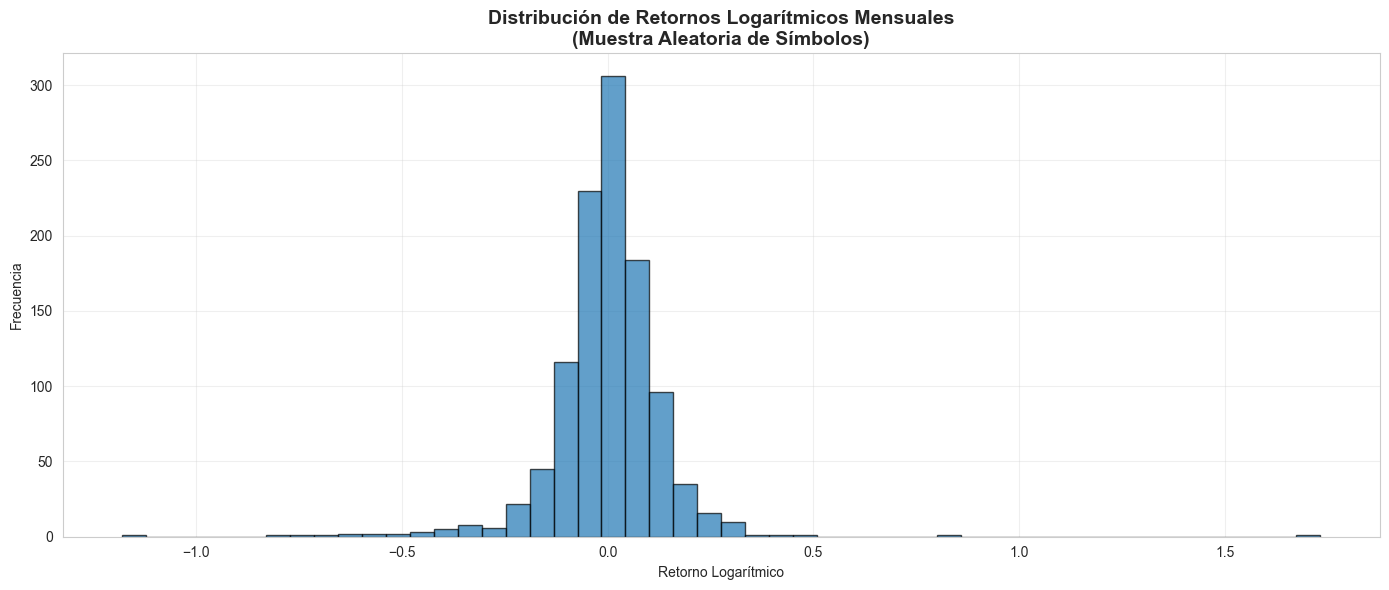

In [12]:
# Estadísticas de retornos
print("> Estadísticas de retornos logarítmicos mensuales:")
display(df_log_returns.describe())

# Visualización: distribución de retornos
fig, ax = plt.subplots(figsize=(14, 6))

# Fijamos la semilla para que la muestra aleatoria sea reproducible
np.random.seed(42)

# Seleccionamos aleatoriamente un subconjunto de símbolos
# (sin reemplazo) de entre todas las columnas disponibles
cols = np.random.choice(
    df_log_returns.columns,
    size=10,          # número de símbolos muestreados
    replace=False
)

# Extraemos los retornos de los símbolos seleccionados
# y los aplanamos en un solo vector
sample_returns = df_log_returns[cols].values.flatten()

# Eliminamos valores NaN generados por el shift temporal
sample_returns = sample_returns[~np.isnan(sample_returns)]

# Histograma de la distribución de retornos logarítmicos mensuales
ax.hist(
    sample_returns,
    bins=50,
    edgecolor='black',
    alpha=0.7
)

ax.set_title(
    'Distribución de Retornos Logarítmicos Mensuales\n(Muestra Aleatoria de Símbolos)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Retorno Logarítmico')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha=0.3)

# Ajuste de layout
plt.tight_layout()
plt.show()

> <u>Comentario</u>: Las estadísticas y el histograma muestran la distribución de los retornos mensuales del universo. La dispersión y asimetría son coherentes con datos de renta variable; los datos están listos para la estrategia del Notebook 3.

> <u>Nota</u>: Para evitar que activos con más observaciones dominen la distribución y para reducir la carga computacional, el histograma se construye a partir de una muestra aleatoria de símbolos (columnas), no del universo completo.

## <font color=#0099CC>**7. RESUMEN FINAL**</font>

Resumen de los artefactos generados: retornos logarítmicos mensuales, precios mensuales (open/close) e histórico filtrado, listos para el Notebook 3 (estrategia) y el Notebook 4 (backtest).

In [13]:
print("-------- RESUMEN DE PREPARACIÓN DE DATOS ---------")

print(f"\n> Periodo de backtesting: {backtest_start.date()} a {backtest_end.date()}")
print(f"> Activos únicos en el dataset: {df_log_returns.shape[1]}")
meses_backtest = df_log_returns.loc[backtest_start:backtest_end].shape[0]
print(f"> Meses de datos (en periodo de backtest): {meses_backtest}")

print(f"\n> Archivos generados:")
print("  - log_returns_monthly.parquet")
print("  - monthly_close_prices.parquet")
print("  - monthly_open_prices.parquet")
print("  - spy_log_returns_monthly.parquet")
print("\n--------------------------------------------------")

-------- RESUMEN DE PREPARACIÓN DE DATOS ---------

> Periodo de backtesting: 2015-01-01 a 2026-01-30
> Activos únicos en el dataset: 1234
> Meses de datos (en periodo de backtest): 132

> Archivos generados:
  - log_returns_monthly.parquet
  - monthly_close_prices.parquet
  - monthly_open_prices.parquet
  - spy_log_returns_monthly.parquet

--------------------------------------------------


> <u>Comentario</u>: Con los Parquet generados (retornos mensuales, precios mensuales open/close e histórico filtrado) el flujo de datos queda cerrado y listo para el Notebook 3 (señales de momentum) y el Notebook 4 (motor de backtest).